# CSF-to-Brain Volume Ratio (CSF2BVR) — MRI Adaptation

Adapted from [Sharada Samadani's CT-based pipeline](https://github.com/samadanilab/Ventriculomegaly-Feature-Computation) for T1-weighted MRI.

**What is CSF2BVR?**
A simple volume ratio: `ventricle voxel count / total brain voxel count`. It quantifies how enlarged the brain's ventricles are — a biomarker for ventriculomegaly, which correlates with hydrocephalus, TBI, and dementia. A healthy young brain is ~0.02–0.04; an older or diseased brain with enlarged ventricles can be 0.10+.

**Key changes from CT version:**
- **Removed Hounsfield Unit (HU) windowing** — CT has standardized intensity units (air=-1000, water=0, bone=~1000), so Sharada hardcoded `window_stack_sitk(img, 50, 100)` to isolate brain tissue. MRI has no standardized intensity units — the same tissue can be 200 in one scan and 800 in another depending on scanner/sequence.
- **Otsu thresholding works as-is** — it finds the optimal intensity split by looking at the histogram shape, not absolute values. Whether CSF peaks at 50 or 500, Otsu finds the valley between the two populations.
- Using skull-stripped, atlas-registered OASIS volumes directly
- Validation against OASIS FSL FAST segmentation

**Reference paper:** https://thejns.org/view/journals/j-neurosurg/141/3/article-p822.xml

## Library imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import cv2 as cv
import SimpleITK as sitk
from skimage import filters
import matplotlib.pyplot as plt

## Configuration

Set `DATASET` to match your data source. The notebook adapts file discovery and validation accordingly.

Supported datasets:
- **`"oasis1"`** — OASIS-1 cross-sectional (skull-stripped, atlas-registered `.img` files)
- **`"abcd"`** — ABCD Study T1w scans (ART-corrected `.nii`/`.nii.gz` files)
- **`"custom"`** — Any NIfTI dataset; set `SCAN_GLOB` to your file pattern

In [ ]:
# ── Choose your dataset ──────────────────────────────────────────────
DATASET = "oasis1"  # "oasis1", "abcd", or "custom"

# ── Dataset-specific settings ────────────────────────────────────────
if DATASET == "oasis1":
    DATA_DIR = "data/oasis1/disc1"
    DEMOGRAPHICS_PATH = "data/oasis1/oasis_cross-sectional-5708aa0a98d82080.xlsx"
    # OASIS skull-stripped, gain-field corrected, atlas-registered volumes
    SCAN_GLOB = "OAS1_*/PROCESSED/MPRAGE/T88_111/*_masked_gfc.img"
    SUBJECT_ID_FROM_PATH = lambda p: p.split(os.sep)[-5]  # e.g. OAS1_0001_MR1

elif DATASET == "abcd":
    DATA_DIR = "data/abcd"
    DEMOGRAPHICS_PATH = None  # set path to ABCD demographics CSV/TSV if available
    # ART-corrected T1w scans (output from Charlie's ART batch script)
    SCAN_GLOB = "**/*_T1w_acpc.nii*"
    SUBJECT_ID_FROM_PATH = lambda p: os.path.basename(p).split("_ses")[0]  # e.g. sub-NDARINVXXXXXXXX

elif DATASET == "custom":
    DATA_DIR = "data/my_dataset"
    DEMOGRAPHICS_PATH = None
    SCAN_GLOB = "**/*.nii.gz"  # adjust to your file naming
    SUBJECT_ID_FROM_PATH = lambda p: os.path.basename(p).replace(".nii.gz", "").replace(".nii", "")

else:
    raise ValueError(f"Unknown DATASET: {DATASET!r}. Use 'oasis1', 'abcd', or 'custom'.")

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Dataset: {DATASET}")
print(f"Data dir: {DATA_DIR}")
print(f"Scan pattern: {SCAN_GLOB}")

## Function definitions

**`rotate_image`** — SimpleITK reads NIfTI files in LPS coordinates (Left-Posterior-Superior), but OASIS data uses RAS (Right-Anterior-Superior). Without this rotation, axial slices appear flipped. This resamples the volume to identity direction cosines so brain images display in the correct anatomical orientation.

**`ventricle_fullbrain_seg`** — The core segmentation function. For each axial slice:
1. **Otsu threshold** — adaptively finds the intensity that best splits dark (CSF) from bright (brain tissue). This replaces Sharada's hardcoded HU windowing.
2. **Floodfill from corner (0,0)** — the top-left pixel is guaranteed background in skull-stripped data. Filling all connected background and inverting gives the **full brain mask** (everything inside the brain boundary, including ventricles).
3. **Ventricles = brain_mask - thresholded_tissue** — the brain mask includes ventricle cavities, but the Otsu binary doesn't (ventricles are dark). The difference = dark regions *inside* the brain = ventricles and internal CSF spaces.

In [3]:
def rotate_image(image, dimension=3):
    """Rotates image from LPS (SimpleITK default) to RAS (NIfTI standard) for correct visualization.
    
    Resamples the image so axial slices appear upright.
    """
    transform = sitk.AffineTransform(dimension)
    transform.SetCenter(image.TransformContinuousIndexToPhysicalPoint(np.array(image.GetSize()) // 2.0))
    matrix = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])
    transform.SetMatrix(matrix.ravel())

    extreme_points = [
        image.TransformIndexToPhysicalPoint((0, 0, 0)),
        image.TransformIndexToPhysicalPoint((image.GetWidth(), 0, 0)),
        image.TransformIndexToPhysicalPoint((image.GetWidth(), image.GetHeight(), 0)),
        image.TransformIndexToPhysicalPoint((0, image.GetHeight(), 0)),
        image.TransformIndexToPhysicalPoint((0, 0, image.GetDepth())),
        image.TransformIndexToPhysicalPoint((image.GetWidth(), 0, image.GetDepth())),
        image.TransformIndexToPhysicalPoint((image.GetWidth(), image.GetHeight(), image.GetDepth())),
        image.TransformIndexToPhysicalPoint((0, image.GetHeight(), image.GetDepth())),
    ]

    inv_transform = transform.GetInverse()
    extreme_points_transformed = [inv_transform.TransformPoint(pnt) for pnt in extreme_points]
    min_x = min(extreme_points_transformed)[0]
    min_y = min(extreme_points_transformed, key=lambda p: p[1])[1]
    min_z = min(extreme_points_transformed, key=lambda p: p[2])[2]

    output_spacing = image.GetSpacing()
    output_direction = [1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0]
    output_origin = [min_x, min_y, min_z]
    output_size = image.GetSize()

    rotated_image = sitk.Resample(
        image, output_size, transform, sitk.sitkLinear,
        output_origin, output_spacing, output_direction
    )
    return rotated_image

In [4]:
def ventricle_fullbrain_seg(ax_img_arr, visualize=True):
    """Segments ventricles and full brain mask from a 3D volume using Otsu + floodfill.

    For T1w MRI: brain tissue is bright, CSF/ventricles are dark.
    Otsu finds the threshold adaptively — no HU windowing needed.

    Returns
    -------
    ventricles : np.ndarray — binary mask of ventricles
    full_brain : np.ndarray — binary mask of full brain
    """
    ventricles = np.zeros(ax_img_arr.shape)
    full_brain = np.zeros(ax_img_arr.shape)

    for pl in range(len(ax_img_arr)):
        ax_plane = ax_img_arr[pl, :, :]

        # Skip empty slices
        if ax_plane.max() == 0:
            continue

        try:
            thresh = filters.threshold_otsu(ax_plane)
        except ValueError:
            continue

        ax_bin = ax_plane > thresh

        # Floodfill from (0,0) to extract background, invert for brain mask
        im_th = ax_bin.copy()
        h, w = im_th.shape[:2]
        mask = np.zeros((h + 2, w + 2), np.uint8)
        im_floodfill = im_th.copy()
        res = cv.floodFill(np.uint8(im_floodfill), mask, (0, 0), 255)

        full_brain_mask = (1 - res[2]).copy()
        full_brain_mask = full_brain_mask[1:h + 1, 1:w + 1]

        ventricles[pl, :, :] = full_brain_mask - ax_bin
        full_brain[pl, :, :] = full_brain_mask

    if visualize:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
        ax1.set_title("Ventricles (IS projection)")
        ax1.imshow(np.sum(ventricles, axis=0), cmap="Greens")
        ax2.set_title("Ventricles (AP projection)")
        ax2.imshow(np.sum(ventricles, axis=1)[::-1, :], cmap="gray")
        ax3.set_title("Ventricles (LR projection)")
        ax3.imshow(np.sum(ventricles, axis=2)[::-1, :], cmap="gray")
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_title("Full brain mask (IS projection)")
        ax.imshow(np.sum(full_brain, axis=0), cmap="gray")
        plt.show()

    return ventricles, full_brain

## Load demographics (optional)

If a demographics file is provided, load it. Otherwise, we'll just compute CSF2BVR without clinical metadata.

In [ ]:
demo_df = None
if DEMOGRAPHICS_PATH and os.path.exists(DEMOGRAPHICS_PATH):
    ext = os.path.splitext(DEMOGRAPHICS_PATH)[1].lower()
    if ext in (".xlsx", ".xls"):
        demo_df = pd.read_excel(DEMOGRAPHICS_PATH)
    elif ext == ".csv":
        demo_df = pd.read_csv(DEMOGRAPHICS_PATH)
    elif ext in (".tsv", ".txt"):
        demo_df = pd.read_csv(DEMOGRAPHICS_PATH, sep="\t")
    else:
        print(f"Unknown demographics format: {ext}")

    if demo_df is not None:
        print(f"Loaded demographics: {len(demo_df)} subjects, columns: {list(demo_df.columns)}")
        demo_df.head()
else:
    print("No demographics file — skipping clinical metadata.")

## Discover available scans

Uses the `SCAN_GLOB` pattern from the configuration cell to find all volumes in `DATA_DIR`.

In [ ]:
scan_files = sorted(glob.glob(os.path.join(DATA_DIR, SCAN_GLOB), recursive=True))

scan_df = pd.DataFrame({
    "subject_id": [SUBJECT_ID_FROM_PATH(p) for p in scan_files],
    "scan_path": scan_files,
})
print(f"Found {len(scan_df)} scans in {DATA_DIR}")
scan_df.head()

## Test on a single subject first

Run the full pipeline on one scan to verify everything works before batch processing.

**What to expect visually (next two cells):**

**Cell 14 — Volume inspection:**
- *Mid-axial slice:* A horizontal cross-section through the middle of the brain. Grey matter appears bright, white matter brighter, ventricles are dark cavities in the center, and background is black (skull-stripped away).
- *Intensity histogram:* Should be roughly bimodal — one cluster of dark voxels (CSF/background residual) and one broad cluster of bright voxels (brain tissue). Otsu will place its threshold in the valley between these two peaks.

**Cell 15 — Ventricle segmentation:**
- *IS (Inferior-Superior) projection:* Looking down from the top of the head. Should show the characteristic **butterfly/horn shape** of the lateral ventricles in green — two symmetric curved structures.
- *AP (Anterior-Posterior) projection:* Looking from the front. Ventricles appear as a bright vertical structure in the center of the brain.
- *LR (Left-Right) projection:* Looking from the side. Ventricles appear as a curved/elongated shape running front-to-back.
- *Full brain mask:* Should look like a solid brain silhouette from above — confirms the floodfill correctly captured the entire brain boundary.

In [ ]:
# Pick first subject
test_path = scan_df.iloc[0]['scan_path']
test_id = scan_df.iloc[0]['subject_id']
print(f"Testing on: {test_id}")
print(f"Path: {test_path}")

# Load the volume
img = sitk.ReadImage(test_path)
print(f"Size: {img.GetSize()}")
print(f"Spacing: {img.GetSpacing()}")
print(f"Direction: {img.GetDirection()}")

Array shape: (176, 208, 176)
Intensity range: [0, 3126]
Mean intensity (non-zero): 887.5


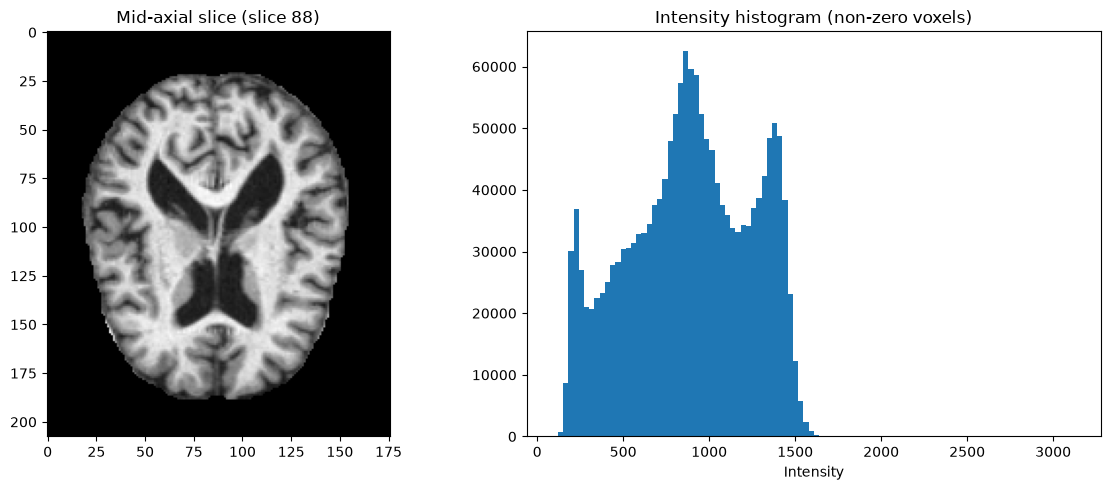

In [8]:
# Rotate to RAS and convert to array
img_rotated = rotate_image(img)
img_arr = sitk.GetArrayFromImage(img_rotated)

print(f"Array shape: {img_arr.shape}")
print(f"Intensity range: [{img_arr.min()}, {img_arr.max()}]")
print(f"Mean intensity (non-zero): {img_arr[img_arr > 0].mean():.1f}")

# Show a mid-axial slice to verify orientation
mid_slice = img_arr.shape[0] // 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.set_title(f"Mid-axial slice (slice {mid_slice})")
ax1.imshow(img_arr[mid_slice, :, :], cmap="gray")
ax2.set_title("Intensity histogram (non-zero voxels)")
ax2.hist(img_arr[img_arr > 0].flatten(), bins=100)
ax2.set_xlabel("Intensity")
plt.tight_layout()
plt.show()

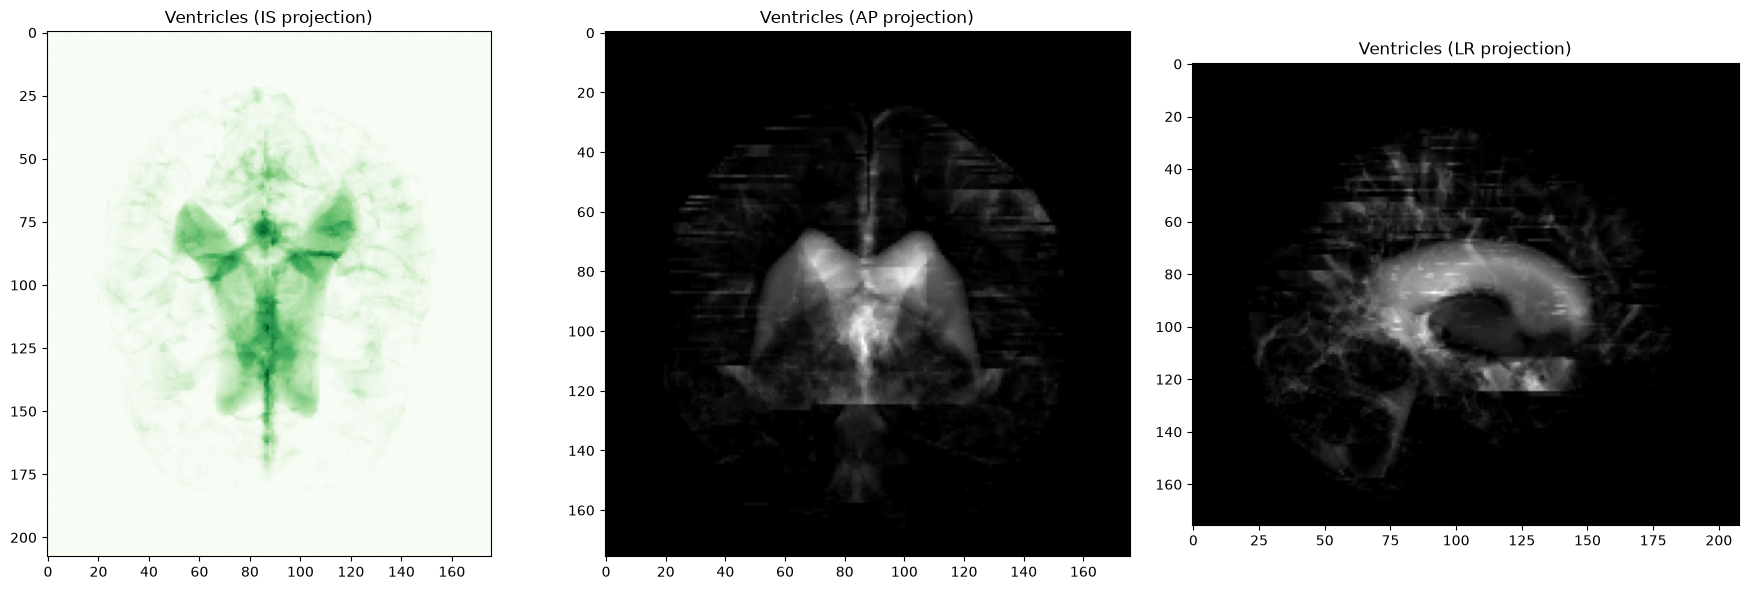

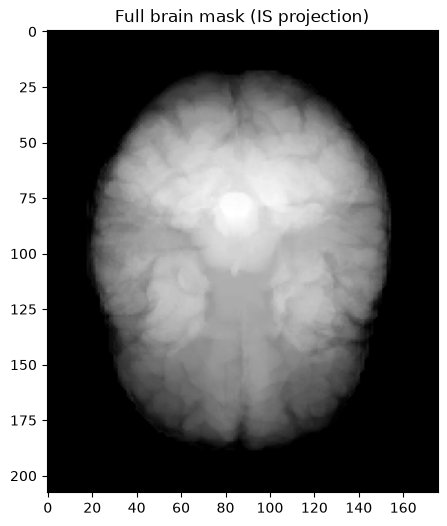


CSF2BVR for OAS1_0001_MR1: 0.0982


In [9]:
# Run ventricle segmentation (no windowing — key MRI adaptation)
# On CT, Sharada applied window_stack_sitk(img, 50, 100) here.
# On T1w MRI, Otsu thresholding works directly on the raw intensities
# because brain tissue is bright and CSF is dark.
ventricles, full_brain = ventricle_fullbrain_seg(img_arr, visualize=True)

csf2bvr = np.sum(ventricles) / np.sum(full_brain)
print(f"\nCSF2BVR for {test_id}: {csf2bvr:.4f}")

## Validate against FSL FAST segmentation (OASIS only)

OASIS provides FSL FAST tissue segmentation for each subject (labels: 1=CSF, 2=grey matter, 3=white matter). We compare our Otsu-based CSF2BVR against FSL's CSF volume ratio as a sanity check. **This section only runs for OASIS data.**

**Why our values are lower than FSL:** Our method captures ventricles specifically (dark regions *inside* the brain mask). FSL captures all CSF everywhere. So our CSF2BVR ≈ 0.03–0.15 while FSL's ≈ 0.10–0.32. This is correct and expected.

In [ ]:
if DATASET == "oasis1":
    # Load FSL segmentation for the test subject
    test_dir = os.path.join(DATA_DIR, test_id)
    fseg_files = glob.glob(os.path.join(test_dir, "FSL_SEG", "*_fseg.img"))

    if fseg_files:
        fseg_img = sitk.ReadImage(fseg_files[0])
        fseg_arr = sitk.GetArrayFromImage(fseg_img)

        # FSL FAST labels: 1=CSF, 2=GM, 3=WM
        fsl_csf = np.sum(fseg_arr == 1)
        fsl_brain = np.sum(fseg_arr > 0)
        fsl_csf2bvr = fsl_csf / fsl_brain

        print(f"Our CSF2BVR:  {csf2bvr:.4f}")
        print(f"FSL CSF2BVR:  {fsl_csf2bvr:.4f}")
        print(f"Difference:   {abs(csf2bvr - fsl_csf2bvr):.4f}")

        fseg_rotated = rotate_image(fseg_img)
        fseg_rot_arr = sitk.GetArrayFromImage(fseg_rotated)
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        ax1.set_title("Our ventricle segmentation")
        ax1.imshow(ventricles[mid_slice, :, :], cmap="Greens")
        ax2.set_title("FSL FAST CSF (label=1)")
        ax2.imshow(fseg_rot_arr[mid_slice, :, :] == 1, cmap="Greens")
        ax3.set_title("Original MRI")
        ax3.imshow(img_arr[mid_slice, :, :], cmap="gray")
        plt.tight_layout()
        plt.show()
    else:
        print("No FSL segmentation found for this subject.")
else:
    print(f"FSL validation skipped (dataset={DATASET}, only available for oasis1).")

## Batch processing — all disc 1 subjects

Run the same pipeline on all 39 subjects with visualization off. Also computes FSL reference values for each subject so we can validate at scale.

In [ ]:
results = []

for _, row in scan_df.iterrows():
    subject_id = row['subject_id']
    vol_path = row['scan_path']

    try:
        img = sitk.ReadImage(vol_path)
        img_arr = sitk.GetArrayFromImage(rotate_image(img))

        ventricles, full_brain = ventricle_fullbrain_seg(img_arr, visualize=False)
        csf2bvr = np.sum(ventricles) / np.sum(full_brain) if np.sum(full_brain) > 0 else np.nan

        # FSL validation (OASIS only)
        fsl_csf2bvr = np.nan
        if DATASET == "oasis1":
            fseg_files = glob.glob(os.path.join(DATA_DIR, subject_id, "FSL_SEG", "*_fseg.img"))
            if fseg_files:
                fseg_arr = sitk.GetArrayFromImage(sitk.ReadImage(fseg_files[0]))
                fsl_brain = np.sum(fseg_arr > 0)
                if fsl_brain > 0:
                    fsl_csf2bvr = np.sum(fseg_arr == 1) / fsl_brain

        results.append({
            "subject_id": subject_id,
            "csf2bvr": csf2bvr,
            "fsl_csf2bvr": fsl_csf2bvr,
        })
        print(f"{subject_id}: CSF2BVR={csf2bvr:.4f}" + (f", FSL={fsl_csf2bvr:.4f}" if not np.isnan(fsl_csf2bvr) else ""))

    except Exception as e:
        print(f"{subject_id}: ERROR — {e}")
        results.append({"subject_id": subject_id, "csf2bvr": np.nan, "fsl_csf2bvr": np.nan})

results_df = pd.DataFrame(results)
print(f"\nProcessed {len(results_df)} subjects")

## Results analysis

**What to expect in the three plots:**

1. **Our CSF2BVR vs FSL CSF2BVR (left):** Scatter plot with y=x reference line. Points should show a strong positive correlation (both increase together) but sit *below* the y=x line — our values are systematically lower because we measure ventricles only, FSL measures all CSF. A high Pearson r (>0.8) confirms our method tracks the same underlying signal.

2. **CSF2BVR distribution (middle):** Histogram across all 39 subjects. Expect a right-skewed distribution with most values between 0.03–0.10, and a few higher outliers (older subjects or those with dementia).

3. **CSF2BVR by CDR group (right):** Overlapping histograms colored by dementia severity. CDR 0 (healthy) should cluster at lower values, CDR 0.5 (very mild) and CDR 1.0 (mild dementia) should shift rightward — confirming the biomarker has clinical discriminative value.

In [ ]:
# Merge with demographics if available
if demo_df is not None:
    # Try common ID column names
    id_col = next((c for c in demo_df.columns if c.upper() in ("ID", "SUBJECT_ID", "SUBJECTKEY", "SRC_SUBJECT_ID")), None)
    if id_col:
        merge_cols = [id_col] + [c for c in demo_df.columns if c != id_col and c in ('Age', 'M/F', 'CDR', 'Sex', 'age', 'sex', 'interview_age')]
        results_df = results_df.merge(demo_df[merge_cols], left_on='subject_id', right_on=id_col, how='left')

# Plot FSL validation only if we have FSL data
has_fsl = 'fsl_csf2bvr' in results_df.columns and results_df['fsl_csf2bvr'].notna().any()
has_cdr = 'CDR' in results_df.columns and results_df['CDR'].notna().any()

n_plots = 1 + int(has_fsl) + int(has_cdr)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
if n_plots == 1:
    axes = [axes]
plot_idx = 0

# FSL validation scatter
if has_fsl:
    valid = results_df.dropna(subset=['csf2bvr', 'fsl_csf2bvr'])
    corr = valid['csf2bvr'].corr(valid['fsl_csf2bvr'])
    axes[plot_idx].scatter(valid['fsl_csf2bvr'], valid['csf2bvr'], alpha=0.7)
    axes[plot_idx].plot([0, 0.4], [0, 0.4], 'r--', label='y=x')
    axes[plot_idx].set_xlabel('FSL FAST CSF2BVR')
    axes[plot_idx].set_ylabel('Our CSF2BVR')
    axes[plot_idx].set_title(f'Validation vs FSL (r={corr:.3f})')
    axes[plot_idx].legend()
    plot_idx += 1

# CSF2BVR distribution
axes[plot_idx].hist(results_df['csf2bvr'].dropna(), bins=20, edgecolor='black')
axes[plot_idx].set_xlabel('CSF2BVR')
axes[plot_idx].set_ylabel('Count')
axes[plot_idx].set_title('CSF2BVR Distribution')
plot_idx += 1

# CSF2BVR by CDR (if available)
if has_cdr:
    for cdr_val in sorted(results_df['CDR'].dropna().unique()):
        subset = results_df[results_df['CDR'] == cdr_val]['csf2bvr'].dropna()
        if len(subset) > 0:
            axes[plot_idx].hist(subset, bins=15, alpha=0.5, label=f'CDR {cdr_val}')
    axes[plot_idx].set_xlabel('CSF2BVR')
    axes[plot_idx].set_ylabel('Count')
    axes[plot_idx].set_title('CSF2BVR by Dementia Severity')
    axes[plot_idx].legend()

plt.tight_layout()
plt.show()

# Summary stats
print(f"\nCSF2BVR summary (n={results_df['csf2bvr'].notna().sum()}):")
print(results_df['csf2bvr'].describe().round(4))
if has_cdr:
    print("\nCSF2BVR by CDR group:")
    print(results_df.groupby('CDR')['csf2bvr'].describe().round(4))

In [ ]:
output_path = os.path.join(OUTPUT_DIR, f"csf2bvr_{DATASET}.csv")
results_df.to_csv(output_path, index=False)
print(f"Results saved to {output_path}")